In [181]:
#@@ Abdelhak Tarek

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [183]:
df = pd.read_csv('customer_data.csv')

In [184]:
df

,Age,Income,Spending_Score
0,56,54081.631580,6
1,69,81987.547764,35
2,46,NaN,38
3,32,82267.210119,35
4,60,60702.533399,74
...,...,...,...
5495,48,47727.944720,33
5496,32,17689.770578,53
5497,33,79435.629555,93
5498,30,68391.386866,392


In [185]:
df.dropna(inplace=True)

In [186]:
df.head()

,Age,Income,Spending_Score
0,56,54081.631580,6
1,69,81987.547764,35
3,32,82267.210119,35
4,60,60702.533399,74
5,25,37820.066136,94


In [187]:
df.describe()

,Age,Income,Spending_Score
count,5350.000000,5350.000000,5350.000000
mean,43.670280,60066.712836,52.162804
std,14.955511,19897.082356,41.259660
min,18.000000,-14175.932186,1.000000
25%,31.000000,46762.535031,25.000000
50%,44.000000,60127.949617,50.000000
75%,56.000000,73605.858277,74.000000
max,69.000000,133154.036080,496.000000


In [188]:
df = df[(df['Income'] > 0) & (df['Spending_Score'] > 0)& (df['Spending_Score'] < 200)]

In [189]:
WCSS = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df)
    WCSS.append(kmeans.inertia_)

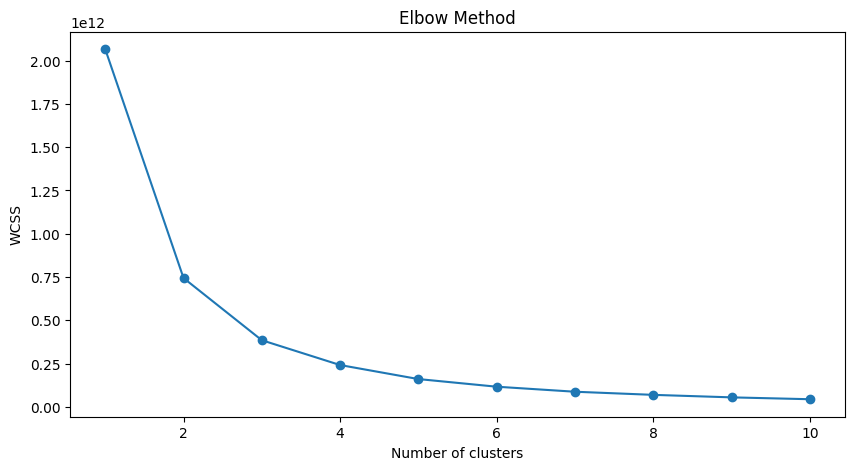

In [190]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), WCSS, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [191]:
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(df)

centroids = kmeans.cluster_centers_

In [192]:
from sklearn.metrics import silhouette_score
silhouette_score = silhouette_score(df[['Spending_Score', 'Income','Age']], df['Cluster'])
print(f'Silhouette Score: {silhouette_score:.3f}')

Silhouette Score: 0.553


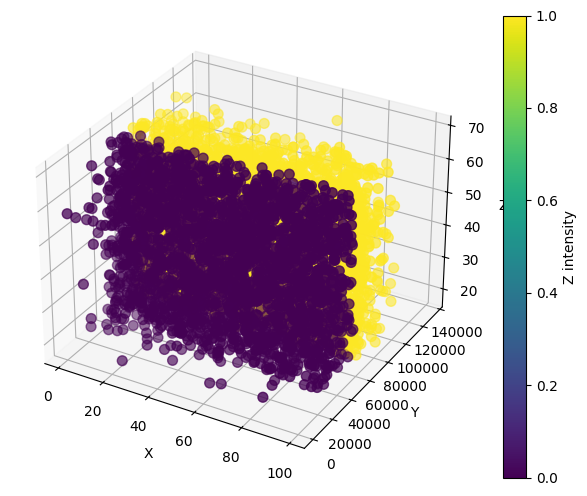

In [193]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Spending_Score'], df['Income'], df['Age'], c=df['Cluster'], cmap='viridis', s=50)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
fig.colorbar(scatter, label='Z intensity')
plt.show()

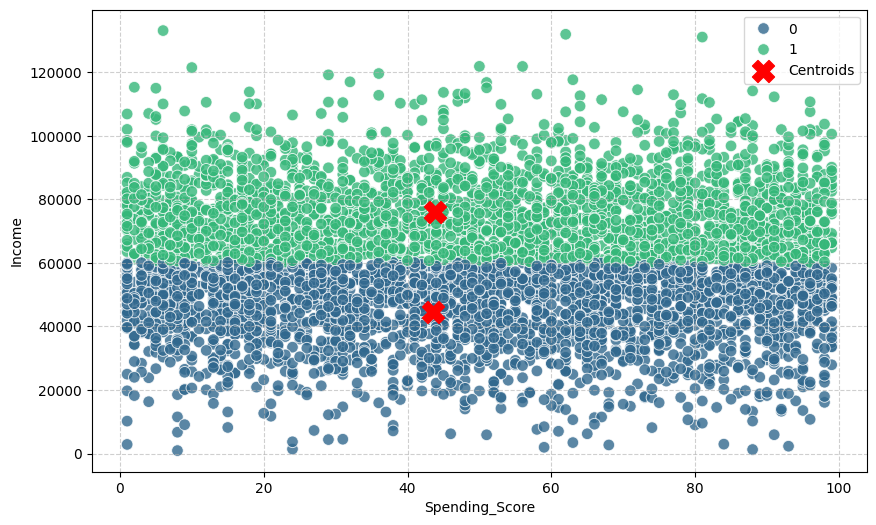

In [194]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Spending_Score', 
    y='Income', 
    hue='Cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=250, 
    c='red', 
    marker='X', 
    label='Centroids'
)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()